In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Build path to data folder ──
data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'assets', 'data'))
print(f'Looking for data in: {data_dir}')
print(f'Files found: {os.listdir(data_dir)}')

# ── Load Cleaned CSV (double space before (Cleaned)) ──
data = pd.read_csv(os.path.join(data_dir, 'Student Study Hours & Academic Performance Survey (Cleaned).csv'))
data.info()
print(f'\nDataset shape: {data.shape[0]} rows × {data.shape[1]} columns')
print(f'\nCGPA distribution:')
print(data['cgpa'].value_counts().sort_index())

Looking for data in: c:\Users\andly\Documents\Y2 S2\DVID\Student Academic Performance Dashboard\assets\data
Files found: ['Student Study Hours & Academic Performance Survey (Cleaned).csv', 'Student Study Hours & Academic Performance Survey (RAW).csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 36 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   study_hours_daily                                       88 non-null     float64
 1   study_hours_exam                                        88 non-null     int64  
 2   time_management                                         88 non-null     int64  
 3   reading_plan                                            88 non-null     int64  
 4   note_taking                                             88 non-null     int64  
 5   group_study                                  

# Data Splitting

In [2]:
from sklearn.model_selection import train_test_split

# Target variable: CGPA mapped to string class labels
X = data.drop(columns=['cgpa'])
y = data['cgpa'].map({
    2.75: 'Low',
    3.25: 'Mid',
    3.75: 'High'
})

# Split 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.70, random_state=42, stratify=y
)

print('Training Set:', X_train.shape, y_train.shape)
print('Testing Set: ', X_test.shape,  y_test.shape)
print()
print('Class distribution in training set:')
print(y_train.value_counts())

Training Set: (61, 35) (61,)
Testing Set:  (27, 35) (27,)

Class distribution in training set:
cgpa
High    39
Mid     19
Low      3
Name: count, dtype: int64


# Resampling (RandomOverSampler)

In [3]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('Before Oversampling:', Counter(y_train))

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print('After Oversampling: ', Counter(y_train_res))
print(f'\nTraining samples increased: {len(y_train)} → {len(y_train_res)}')

Before Oversampling: Counter({'High': 39, 'Mid': 19, 'Low': 3})
After Oversampling:  Counter({'High': 39, 'Mid': 39, 'Low': 39})

Training samples increased: 61 → 117


### Model Training Using RandomOverSampler-Resampled Training Data


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Define all 9 models
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes':   GaussianNB(),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'AdaBoost':               AdaBoostClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)':   MLPClassifier(max_iter=1000, random_state=42),
}

# Train all models on RandomOverSampler-resampled data
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    print(f'{name} trained successfully using RandomOverSampler-resampled training data.')

Logistic Regression trained successfully using RandomOverSampler-resampled training data.
Decision Tree trained successfully using RandomOverSampler-resampled training data.
Support Vector Machine trained successfully using RandomOverSampler-resampled training data.
K-Nearest Neighbors trained successfully using RandomOverSampler-resampled training data.
Gaussian Naive Bayes trained successfully using RandomOverSampler-resampled training data.
Random Forest trained successfully using RandomOverSampler-resampled training data.
Gradient Boosting trained successfully using RandomOverSampler-resampled training data.
AdaBoost trained successfully using RandomOverSampler-resampled training data.
Neural Network (MLP) trained successfully using RandomOverSampler-resampled training data.


# Model Evaluation Metrics

In [5]:
# Predict on the original (non-resampled) test dataset
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

print('Predictions collected for all 9 models.')

Predictions collected for all 9 models.


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate model performance
def evaluate_model(y_true, y_pred):
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

results = {}
for model_name, y_pred in predictions.items():
    results[model_name] = evaluate_model(y_test, y_pred)

results_df = pd.DataFrame(
    results,
    index=['Accuracy', 'Precision', 'Recall', 'F1 Score']
).T.sort_values(by='Accuracy', ascending=False)

results_df = results_df.round(4)
print('=== MODEL EVALUATION ON TEST SET ===')
print(results_df)

=== MODEL EVALUATION ON TEST SET ===
                        Accuracy  Precision  Recall  F1 Score
Logistic Regression       0.6296     0.6326  0.6296    0.6287
K-Nearest Neighbors       0.6296     0.6971  0.6296    0.6407
Random Forest             0.5926     0.5531  0.5926    0.5592
Gradient Boosting         0.5556     0.5426  0.5556    0.5377
Gaussian Naive Bayes      0.5185     0.6466  0.5185    0.5470
AdaBoost                  0.5185     0.3833  0.5185    0.4407
Support Vector Machine    0.4444     0.6942  0.4444    0.5001
Decision Tree             0.4444     0.5048  0.4444    0.4709
Neural Network (MLP)      0.1111     0.1350  0.1111    0.0985


# KFold Cross-Validation

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from tabulate import tabulate

# Redefine models fresh for CV pipeline
models_cv = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'KNN':                    KNeighborsClassifier(),
    'Gaussian NB':            GaussianNB(),
    'Random Forest':          RandomForestClassifier(random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(random_state=42),
    'AdaBoost':               AdaBoostClassifier(random_state=42),
    'MLP':                    MLPClassifier(max_iter=1000, random_state=42),
}

# Stratified 10-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Multiclass-safe scoring
scoring = {
    'accuracy':  make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall':    make_scorer(recall_score,    average='macro', zero_division=0),
    'f1':        make_scorer(f1_score,        average='macro', zero_division=0),
}

# Cross-Validation with RandomOverSampler inside pipeline
cv_results_list = []
for name, model in models_cv.items():
    steps = [('oversample', RandomOverSampler(random_state=42))]

    # Scale only for distance/gradient-based models
    if name in ['Logistic Regression', 'Support Vector Machine', 'KNN', 'MLP']:
        steps.append(('scaler', StandardScaler()))

    steps.append(('model', model))
    pipeline = Pipeline(steps)

    scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring, return_train_score=False)
    cv_results_list.append({
        'Model':     name,
        'Accuracy':  scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall':    scores['test_recall'].mean(),
        'F1 Score':  scores['test_f1'].mean(),
    })

summary_df = pd.DataFrame(cv_results_list).sort_values(by='Accuracy', ascending=False)

print('\n=== CROSS VALIDATION SUMMARY ===')
print(summary_df.round(4).to_string(index=False))

summary_table = tabulate(
    summary_df.round(4), headers='keys',
    tablefmt='fancy_grid', showindex=False, floatfmt='.4f'
)
print(summary_table)

top_models   = summary_df['Model'].head(2).tolist()
worst_models = summary_df['Model'].tail(2).tolist()
print('\nTop 2 Models:',   top_models)
print('Worst 2 Models:', worst_models)



=== CROSS VALIDATION SUMMARY ===
                 Model  Accuracy  Precision  Recall  F1 Score
         Random Forest    0.6347     0.5042  0.4867    0.4657
                   MLP    0.5931     0.4836  0.4833    0.4711
     Gradient Boosting    0.5778     0.4686  0.4606    0.4451
Support Vector Machine    0.5708     0.4172  0.4428    0.4249
   Logistic Regression    0.5708     0.4896  0.4861    0.4612
              AdaBoost    0.5694     0.5039  0.4983    0.4588
                   KNN    0.5458     0.4443  0.4311    0.4231
         Decision Tree    0.4778     0.3310  0.3361    0.3277
           Gaussian NB    0.3875     0.4221  0.3650    0.3120
╒════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model                  │   Accuracy │   Precision │   Recall │   F1 Score │
╞════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Random Forest          │     0.6347 │      0.5042 │   0.4867 │     0.4657 │
├────────────────────────┼────────

# Feature Importance

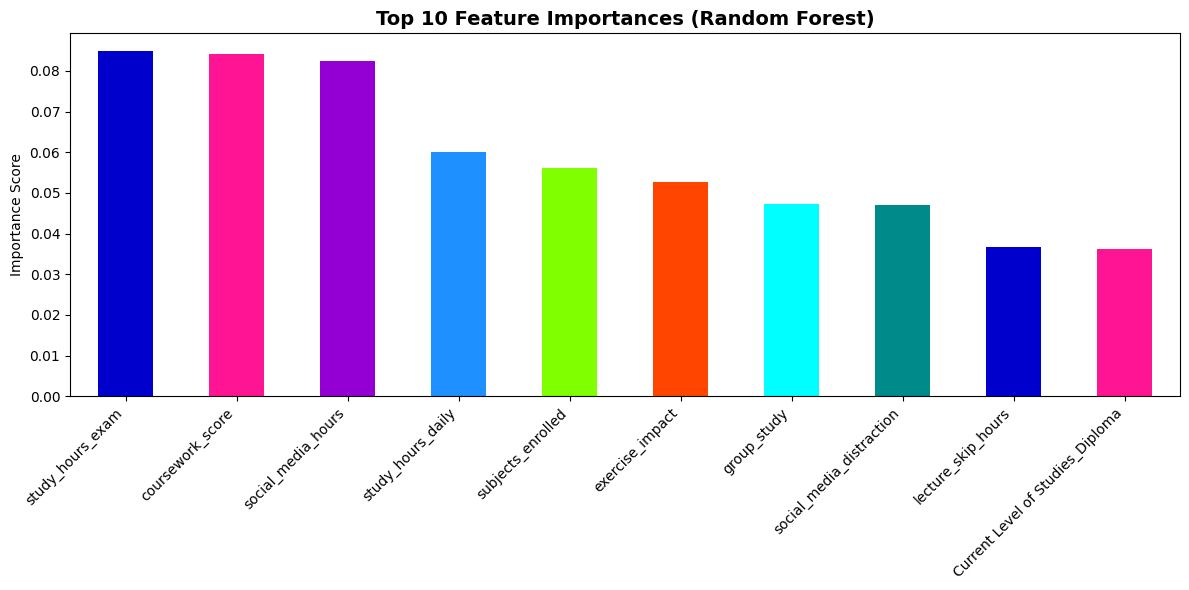

Top 10 Feature Importances:
study_hours_exam                    0.0850
coursework_score                    0.0843
social_media_hours                  0.0824
study_hours_daily                   0.0602
subjects_enrolled                   0.0562
exercise_impact                     0.0526
group_study                         0.0474
social_media_distraction            0.0469
lecture_skip_hours                  0.0367
Current Level of Studies_Diploma    0.0362
dtype: float64


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on full data (no oversampling) for feature importance
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

# Feature Importance
importances = pd.Series(forest.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot top 10
colors = ['mediumblue', 'deeppink', 'darkviolet', 'dodgerblue', 'chartreuse',
          'orangered', 'aqua', 'darkcyan', 'mediumblue', 'deeppink']

plt.figure(figsize=(12, 6))
importances.head(10).plot(kind='bar', color=colors)
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 Feature Importances:')
print(importances.head(10).round(4))

In [9]:
top_features = importances.head(8).index.tolist()
print('Top 8 Features:', top_features)

X_top = data[top_features]
y_top = data['cgpa'].map({2.75: 'Low', 3.25: 'Mid', 3.75: 'High'})  # ← string labels

Top 8 Features: ['study_hours_exam', 'coursework_score', 'social_media_hours', 'study_hours_daily', 'subjects_enrolled', 'exercise_impact', 'group_study', 'social_media_distraction']


# Top Feature ReRun

In [10]:
# Split using top features only
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y_top, train_size=0.70, random_state=42, stratify=y_top
)

print('Top Feature Training Set:', X_train_top.shape)
print('Top Feature Testing Set: ', X_test_top.shape)

Top Feature Training Set: (61, 8)
Top Feature Testing Set:  (27, 8)


In [11]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_top_res, y_train_top_res = ros.fit_resample(X_train_top, y_train_top)

print('Before Oversampling:', Counter(y_train_top))
print('After Oversampling: ', Counter(y_train_top_res))

Before Oversampling: Counter({'High': 39, 'Mid': 19, 'Low': 3})
After Oversampling:  Counter({'High': 39, 'Mid': 39, 'Low': 39})


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

X_top = data[top_features]
y_top = data['cgpa'].map({2.75: 'Low', 3.25: 'Mid', 3.75: 'High'})

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy':  make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall':    make_scorer(recall_score,    average='macro', zero_division=0),
    'f1':        make_scorer(f1_score,        average='macro', zero_division=0),
}

models_top = {
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results_top = []
for name, model in models_top.items():
    pipe = Pipeline([
        ('oversample', RandomOverSampler(random_state=42)),  # ← RandomOverSampler — using RandomOverSampler
        ('model', model)
    ])
    cv_results = cross_validate(
        pipe, X_top, y_top, cv=skf,
        scoring=scoring, return_train_score=False
    )
    results_top.append({
        'Model':     name,
        'Accuracy':  cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall':    cv_results['test_recall'].mean(),
        'F1 Score':  cv_results['test_f1'].mean(),
    })

summary_top_df = pd.DataFrame(results_top).sort_values(by='Accuracy', ascending=False)

print('\n=== CV + RandomOverSampler (Top Features Only) ===')
print(summary_top_df.round(4).to_string(index=False))


=== CV + RandomOverSampler (Top Features Only) ===
            Model  Accuracy  Precision  Recall  F1 Score
    Random Forest    0.6486     0.5712  0.5661    0.5493
Gradient Boosting    0.5917     0.4737  0.4744    0.4643


# Final Model Evaluation Metrics

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Readable class labels
class_labels = ['High', 'Low', 'Mid']  # alphabetical order

# ============================================================
# Random Forest: CV + RandomOverSampler (TOP FEATURES ONLY)
# ============================================================
rf_pipeline = Pipeline([
    ('oversample', RandomOverSampler(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

y_pred_rf_cv = cross_val_predict(rf_pipeline, X_top, y_top, cv=skf)

print('Random Forest — Confusion Matrix (CV + RandomOverSampler + Top Features):')
print(confusion_matrix(y_top, y_pred_rf_cv))

print('\nRandom Forest — Classification Report (CV + RandomOverSampler + Top Features):')
print(classification_report(y_top, y_pred_rf_cv, target_names=class_labels, zero_division=0))

rf_acc = accuracy_score(y_top, y_pred_rf_cv)
print(f'Random Forest Accuracy (CV-based, Top Features Only): {rf_acc * 100:.1f}%')

# ============================================================
# Gradient Boosting: CV + RandomOverSampler (TOP FEATURES ONLY)
# ============================================================
gb_pipeline = Pipeline([
    ('oversample', RandomOverSampler(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

y_pred_gb_cv = cross_val_predict(gb_pipeline, X_top, y_top, cv=skf)

print('\n\nGradient Boosting — Confusion Matrix (CV + RandomOverSampler + Top Features):')
print(confusion_matrix(y_top, y_pred_gb_cv))

print('\nGradient Boosting — Classification Report (CV + RandomOverSampler + Top Features):')
print(classification_report(y_top, y_pred_gb_cv, target_names=class_labels, zero_division=0))

gb_acc = accuracy_score(y_top, y_pred_gb_cv)
print(f'Gradient Boosting Accuracy (CV-based, Top Features Only): {gb_acc * 100:.1f}%')

Random Forest — Confusion Matrix (CV + RandomOverSampler + Top Features):
[[42  0 14]
 [ 0  1  3]
 [13  1 14]]

Random Forest — Classification Report (CV + RandomOverSampler + Top Features):
              precision    recall  f1-score   support

        High       0.76      0.75      0.76        56
         Low       0.50      0.25      0.33         4
         Mid       0.45      0.50      0.47        28

    accuracy                           0.65        88
   macro avg       0.57      0.50      0.52        88
weighted avg       0.65      0.65      0.65        88

Random Forest Accuracy (CV-based, Top Features Only): 64.8%


Gradient Boosting — Confusion Matrix (CV + RandomOverSampler + Top Features):
[[39  2 15]
 [ 1  1  2]
 [14  2 12]]

Gradient Boosting — Classification Report (CV + RandomOverSampler + Top Features):
              precision    recall  f1-score   support

        High       0.72      0.70      0.71        56
         Low       0.20      0.25      0.22         4
    